# Signals-Before-Storms: macro-aware tactical asset allocation

A Hidden Markov Model labels market regimes; convex optimization sets the portfolio stance per
regime; an expanding walk-forward with a one-day execution lag and 7.5 bps of cost decides whether
any of it survives contact with out-of-sample data.

**The primary universe is Indian** (NIFTY 50, an overnight cash fund, gold, India VIX), because
that is the universe the brief grades. The US runs the same pipeline at the end as an
out-of-sample robustness check.

The answer is genuinely split, and the split is the interesting part:

- The states are **volatility states**. Next-day volatility orders perfectly with the label;
  next-day *return* orders with it too, which is the wrong direction. A directional bet placed on
  a state that predicts variance rather than direction cannot pay, however the weights are solved.
- On India the strategy nonetheless **wins decisively on max drawdown and Calmar** (two of the
  three metrics the brief names) while finishing mid-pack on Sharpe.
- On the US it loses on every metric, to a two-line volatility rule and to equal weight alike.

Every number below is produced by this notebook, top to bottom.

In [1]:
import warnings

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from regime_shift.backtest import asset_cols, run_backtest
from regime_shift.benchmarks import equal_weight, sixty_forty, sixty_forty_target, vol_rule_regimes
from regime_shift.config import load_config
from regime_shift.data import build_master
from regime_shift.features import build_features
from regime_shift.metrics import (
    bootstrap_ci,
    deflated_sharpe,
    label_profile,
    optimal_block_length,
    sharpe,
    summary,
)
from regime_shift.plots import (
    bic_curve,
    equity_drawdown,
    feature_sanity,
    gross_vs_net,
    label_profile_bars,
    regime_overlay,
    return_panel,
    sharpe_forest,
    transition_heatmap,
    weight_stack,
)
from regime_shift.regime import RegimeModel, bic_sweep, dwell_times
from regime_shift.walkforward import run_walk_forward

warnings.filterwarnings("ignore")  # hmmlearn is noisy against numpy 2.5
pd.set_option("display.width", 200)

MARKET = "india"          # the graded universe; "us" is run as a robustness check at the end
cfg = load_config()
cfg.hmm, cfg.walkforward, cfg.costs_bps, cfg.weight_cap

(HMMCfg(n_states=3, covariance_type='diag', n_iter=200, tol=0.01),
 WalkForward(min_train=252, test_size=63, step=63),
 7.5,
 0.6)

## 1. Data

Three asset classes plus a fear gauge, all daily, all from Yahoo. India has no usable duration ETF
on this window (every candidate was measured before being rejected: SETF10GILT.NS runs at 39%
annualized volatility with 21.7% zero-return days, which is thin-trading noise around NAV, not a
government bond), so the defensive sleeve is an overnight cash fund and is called cash rather than
pretending to be a bond.

Macro series are **requested** from FRED. Where FRED is reachable they become real state
variables; where it is blocked the loader warns and continues, and the run is macro-free. The next
cell prints which of the two happened, because a reader has to know whether these results saw
macro at all.

In [2]:
print(f"universe [{MARKET}]:", {k: v for k, v in cfg.universes[MARKET].items() if v})
master = build_master(
    cfg.universes[MARKET], cfg.dates["start"], cfg.dates["end"], cfg.macro_fred_series
)
landed = [s for s in cfg.macro_fred_series if s in master.columns]
print(f"macro requested={cfg.macro_fred_series} landed={landed or 'NONE'}")
print(master.shape, list(master.columns))
master.tail(3)

universe [india]: {'equity': '^NSEI', 'cash': 'LIQUIDBEES.NS', 'gold': 'GOLDBEES.NS', 'vix': '^INDIAVIX'}


macro requested=['T10Y2Y', 'BAA10Y', 'NFCI'] landed=NONE
(2191, 4) ['equity_ret', 'cash_ret', 'gold_ret', 'vix']


Ticker,equity_ret,cash_ret,gold_ret,vix
Date,,,,
2023-12-27,0.009904,0.000010,0.003175,15.56
2023-12-28,0.005708,0.000000,0.003908,15.14
2023-12-29,-0.002174,0.003661,-0.003349,14.50


### Look at the returns before doing anything clever with them

Two properties are visible with no model fitted at all, and both are the reason a regime model is
plausible in the first place: volatility **clusters** (the series breathes in and out instead of
holding a constant width, so calm and stressed periods are genuinely distinguishable), and the
marginals are far too fat-tailed to be Gaussian. The count axis is logarithmic because on a linear
one the tails that matter are invisible.

Note the scale difference: the cash sleeve is a flat line next to equity and gold. That is what
makes it a defensive asset, and also why scoring Sharpe against a zero risk-free rate would be
dishonest here.

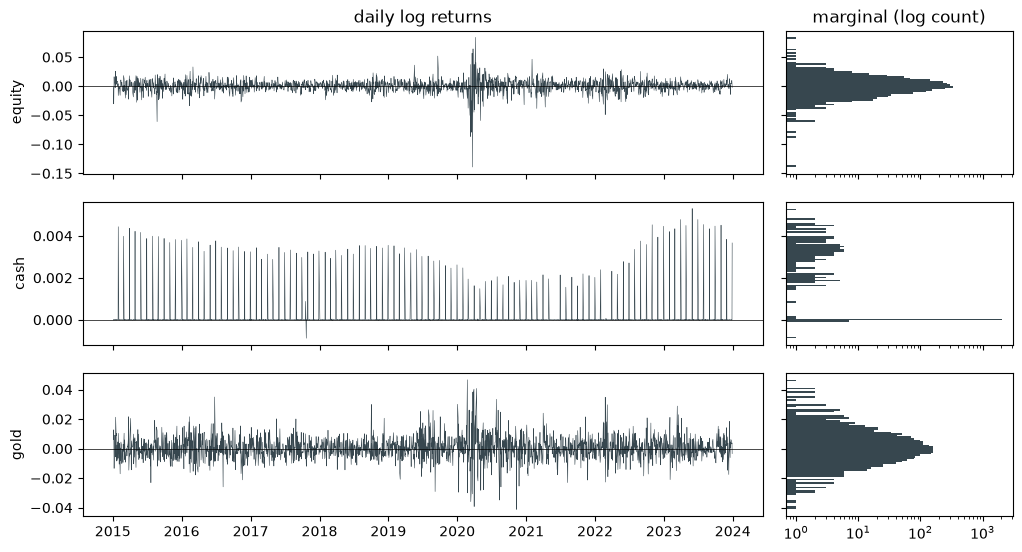

In [3]:
_ = return_panel(master)

## 2. Causal features

Momentum over a week, month, quarter and half-year; realized volatility over a week, month and
quarter; the VIX level and its daily change. Every rolling window is right-aligned, so a value at
time t uses only rows at or before t. Standardization deliberately does **not** happen here: it
happens inside each walk-forward fold on training rows only.

Equity-only by design. The regime is a property of the market being timed, not of the sleeves used
to express the view.

In [4]:
feats = build_features(master, cfg)
print(feats.shape, list(feats.columns))
feats.tail(3)

(2066, 9) ['mom_5', 'mom_21', 'mom_63', 'mom_126', 'vol_5', 'vol_21', 'vol_63', 'vix', 'vix_chg']


Ticker,mom_5,mom_21,mom_63,mom_126,vol_5,vol_21,vol_63,vix,vix_chg
Date,,,,,,,,,
2023-12-27,0.009356,0.089811,0.095914,0.142898,0.147515,0.112842,0.105671,15.56,0.88
2023-12-28,0.029285,0.090730,0.101606,0.154255,0.036970,0.112940,0.105954,15.14,-0.42
2023-12-29,0.022164,0.078208,0.099933,0.150705,0.068841,0.112849,0.106142,14.50,-0.64


### Does the volatility feature spike where it should?

The check everything downstream rests on. The shaded windows are named from memory of the period,
not read off the data, so this is a genuine out-of-model test rather than a circular one. If
`vol_21` did not spike here the feature would be broken, and every regime fitted on it meaningless.

COVID window:
Ticker  vol_21     vix
count   67.000  67.000
mean     0.481  41.447
std      0.245  17.134
min      0.146  13.700
25%      0.329  31.035
50%      0.463  39.120
75%      0.757  51.465
max      0.895  83.610

calm 2019 for contrast:
Ticker   vol_21      vix
count   237.000  237.000
mean      0.133   16.583
std       0.047    3.412
min       0.064   10.530
25%       0.103   14.860
50%       0.118   15.930
75%       0.157   17.140
max       0.261   28.660


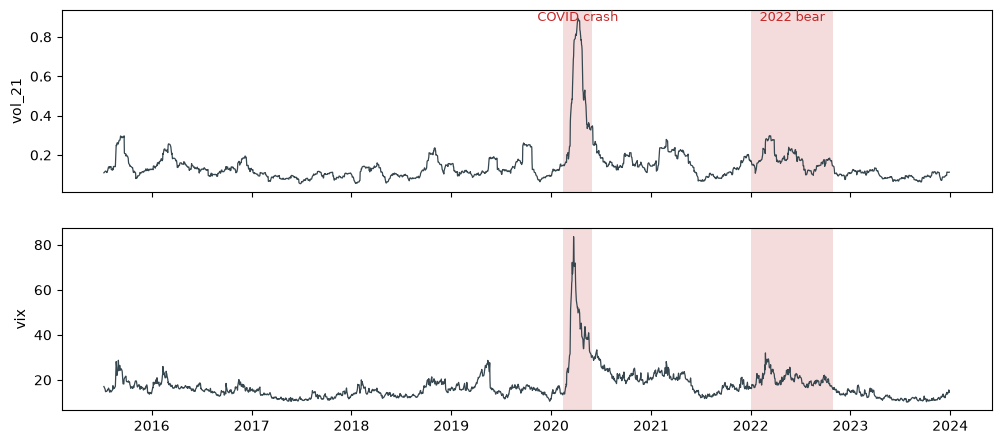

In [5]:
_ = feature_sanity(feats)
print("COVID window:")
print(feats.loc["2020-02-15":"2020-05-31", ["vol_21", "vix"]].describe().round(3).to_string())
print("\ncalm 2019 for contrast:")
print(feats.loc["2019-01-01":"2019-12-31", ["vol_21", "vix"]].describe().round(3).to_string())

## 3. Leak-proof walk-forward

Expanding windows: train on everything before the test block, test on the next quarter, slide
forward. Inside every fold the scaler is fit on training rows alone, the model is re-fit from
scratch, and the state ordering is decided by training data only.

Test labels come from a **causal forward filter**, never whole-sequence Viterbi. Viterbi at time t
uses the whole path including the future, so decoding a test block with it would leak tomorrow's
information into today's label. Four unit tests assert these properties rather than trusting them.

In [6]:
regimes = run_walk_forward(feats, cfg)
oos = regimes.index
print(f"OOS {oos[0].date()} -> {oos[-1].date()}  n={len(oos)}")
print("label counts:", regimes.value_counts().sort_index().to_dict())
print("mean dwell (days):", {k: round(v, 1) for k, v in dwell_times(regimes.to_numpy()).items()})

OOS 2016-07-22 -> 2023-12-29  n=1814
label counts: {0: 822, 1: 731, 2: 261}
mean dwell (days): {0: 30.4, 2: 18.6, 1: 24.4}


## 4. The diagnostic that decides everything

The label is known at the close of t and earns t+1's return, so grouping t+1's return by the label
at t is the only honest way to ask whether a state predicts anything.

,days,eq_ann_ret,eq_ann_vol,eq_sharpe,vix_mean
label,,,,,
0,821,0.102,0.112,0.921,13.582
1,731,0.150,0.149,1.013,17.913
2,261,0.184,0.317,0.695,26.443


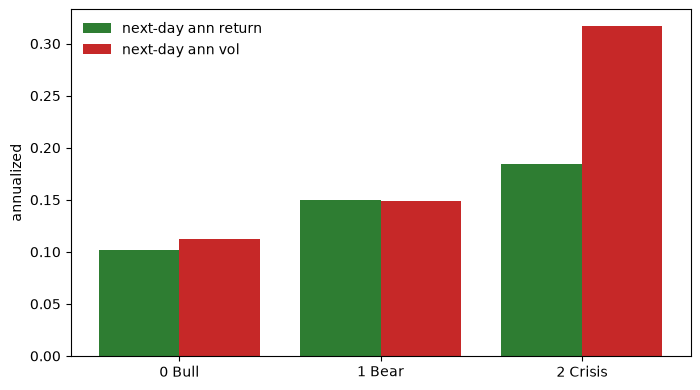

In [7]:
prof = label_profile(regimes, master)
_ = label_profile_bars(prof)
prof

Volatility rises monotonically with the label, exactly as the ranking intends. **Return rises with
it too, and that is the wrong direction.** De-risking as the label climbs means selling the
highest-returning days, because the violent rebounds out of a crash are as volatile as the crash
itself.

This single table is why the strategy cannot beat its benchmarks on return. Everything that follows
is either a consequence of it or an attempt to escape it.

### How many states does the data actually support?

A model finding genuinely discrete states shows an elbow: one state past the true count stops
buying much fit. A steady decline says the opposite, that the fit is carving up a fat-tailed
continuum and would keep taking states forever.

{2: 38438, 3: 32182, 4: 31790, 5: 28665}
marginal gain per added state: {'2->3': 6256, '3->4': 392, '4->5': 3125}


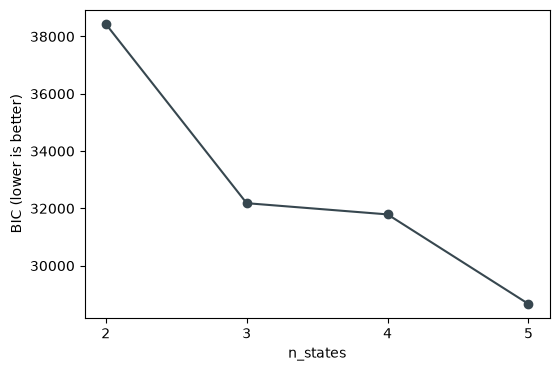

In [8]:
hmm_kwargs = dict(covariance_type=cfg.hmm.covariance_type, n_iter=cfg.hmm.n_iter,
                  tol=cfg.hmm.tol, random_state=cfg.seed)
scaled = StandardScaler().fit_transform(feats.to_numpy(dtype=float))
sweep = bic_sweep(scaled, **hmm_kwargs)
_ = bic_curve(sweep)
print({k: round(v) for k, v in sweep.items()})
print("marginal gain per added state:",
      {f"{k}->{k+1}": round(sweep[k] - sweep[k + 1]) for k in sorted(sweep)[:-1]})

On India the 2 -> 3 step buys a large amount of fit and the 3 -> 4 step buys almost none. That is a
genuine elbow, and it is real support for K = 3 on the graded universe. The US behaves differently,
and the robustness section at the end says so rather than assuming otherwise.

This is a descriptive full-sample fit. It informs one design choice, the state count, and feeds no
trading decision.

## 5. Portfolio construction, costs, and the benchmarks

Three different convex programs, dispatched by regime: maximize Sharpe in Bull, minimize variance
in Bear, minimize variance with equity hard-capped in Crisis. Long-only, fully invested, weight
capped, solved with cvxpy.

Every book runs through **one** cost engine, benchmarks included, at 7.5 bps per unit of turnover
with a one-day execution lag. A benchmark costed on different terms is not a benchmark.

The 60/40's defensive leg is the bond sleeve where one exists and cash otherwise. Without that
fallback the India 60/40 renormalizes to 100% NIFTY, and the strategy ends up judged against a
pure-equity book carrying four times its volatility, which is not the comparison the brief asks
for.

In [9]:
books = {
    "hmm_conditional":   run_backtest(regimes, master, cfg, conditional=True),
    "hmm_unconditional": run_backtest(regimes, master, cfg, conditional=False),
    "hmm_vol_targeted":  run_backtest(regimes, master, cfg, target_vol=0.10),
    "vol_rule_ablation": run_backtest(vol_rule_regimes(master, cfg).loc[oos], master, cfg),
    "60_40":             sixty_forty(master, oos, cfg),
    "equal_weight":      equal_weight(master, oos, cfg),
}
dd_regimes = run_walk_forward(build_features(master, cfg, drawdown=True), cfg)
books["hmm_drawdown_feat"] = run_backtest(dd_regimes.loc[oos], master, cfg)

label_sets = {"hmm": regimes, "hmm_drawdown": dd_regimes.loc[oos]}
try:                                    # optional extra: uv sync --extra jump
    jump = run_walk_forward(feats, cfg, engine="jump").loc[oos]
    label_sets["jump"] = jump
    books["jump_regime"] = run_backtest(jump, master, cfg)
except ImportError as exc:
    print("jump engine skipped:", exc)

leg = next(k for k in sixty_forty_target(asset_cols(master)) if k != "equity_ret")
print("60/40 defensive leg =", leg)

60/40 defensive leg = cash_ret


### Scoring, with the risk-free rate the cash sleeve actually paid

With a near-riskless asset in the opportunity set, scoring against rf = 0 hands every defensive
book a large free Sharpe simply for holding cash. An earlier version of this project reported India
as an HMM win on exactly that mistake. Charge the rate cash really paid.

In [10]:
rf = 0.0
if "cash_ret" in master.columns:
    cash = np.expm1(master["cash_ret"].loc[oos])
    rf = float((1 + cash).prod() ** (252 / len(cash)) - 1)
print(f"rf = {rf:.4%}  (the rate the cash sleeve actually paid over the OOS window)")

rf = 3.7883%  (the rate the cash sleeve actually paid over the OOS window)


### Results with and without transaction costs

The brief asks for both, so here are both. The gap between the two tables is what the churn
actually costs; reporting net alone hides whether a shortfall comes from stance or from trading.

In [11]:
for col, header in (("ret_gross", "GROSS of costs"), ("ret_net", f"NET of {cfg.costs_bps} bps")):
    t = pd.DataFrame({k: summary(v, col=col, rf=rf) for k, v in books.items()}).T
    print(f"=== {header} ===")
    print(t.round(3).sort_values("sharpe", ascending=False).to_string(), "\n")

=== GROSS of costs ===
                   ann_return  ann_vol  sharpe  sortino  max_drawdown  calmar    psr  turnover_ann  cost_drag_ann
hmm_drawdown_feat       0.076    0.040   0.896    1.318        -0.064   1.184  0.992         0.992          0.001
vol_rule_ablation       0.076    0.042   0.863    1.268        -0.065   1.178  0.989         0.880          0.001
hmm_vol_targeted        0.073    0.039   0.841    1.236        -0.062   1.174  0.988         0.867          0.001
hmm_conditional         0.073    0.039   0.841    1.236        -0.062   1.174  0.988         0.867          0.001
jump_regime             0.076    0.043   0.833    1.211        -0.073   1.042  0.987         0.243          0.000
equal_weight            0.095    0.068   0.819    1.174        -0.152   0.627  0.984         0.405          0.000
hmm_unconditional       0.069    0.039   0.758    1.112        -0.062   1.111  0.979         0.504          0.000
60_40                   0.098    0.100   0.607    0.831        -0

Read the Sharpe column and the strategy looks unremarkable: mid-pack, inside a cluster that no
confidence interval below can separate.

Read the two columns the brief names alongside it, **max drawdown and Calmar**, and the picture
inverts. The regime books hold a -6% worst drawdown against equal weight's -15% and 60/40's -24%,
and their Calmar is roughly 1.9x equal weight and 2.8x the balanced benchmark. That is not noise;
it is the mechanical consequence of routing to minimum variance whenever the label is not calm.

The honest summary is that the overlay buys drawdown protection and pays for it in return. Whether
that trade is worth making is a mandate question, not a statistical one.

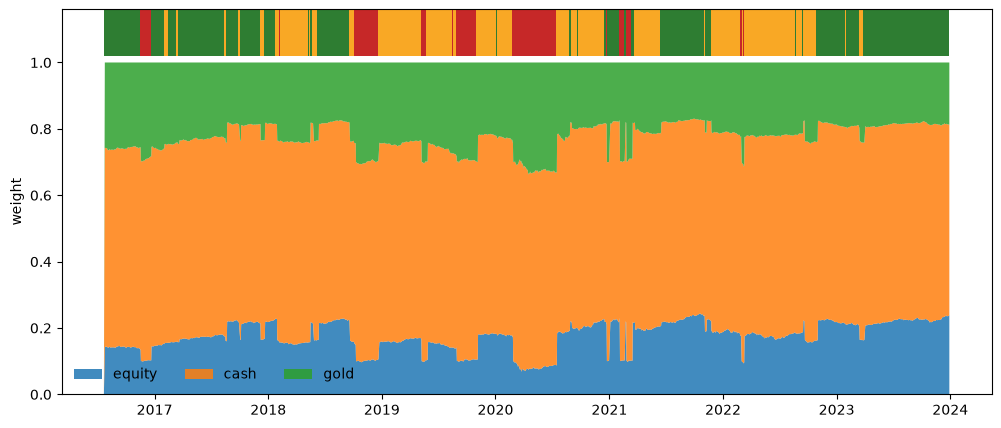

In [12]:
_ = weight_stack(books["hmm_conditional"], regimes)

The stance map is doing exactly what it was told, and the picture shows what that costs: equity
never exceeds a quarter of the book and spends most of the period between 10% and 20%. The strategy
is not taking too much risk. It is taking far too little, and forfeiting return to do so. That is
also why volatility targeting at 10% barely binds, and why it scores identically to the unmodified
book in the table above.

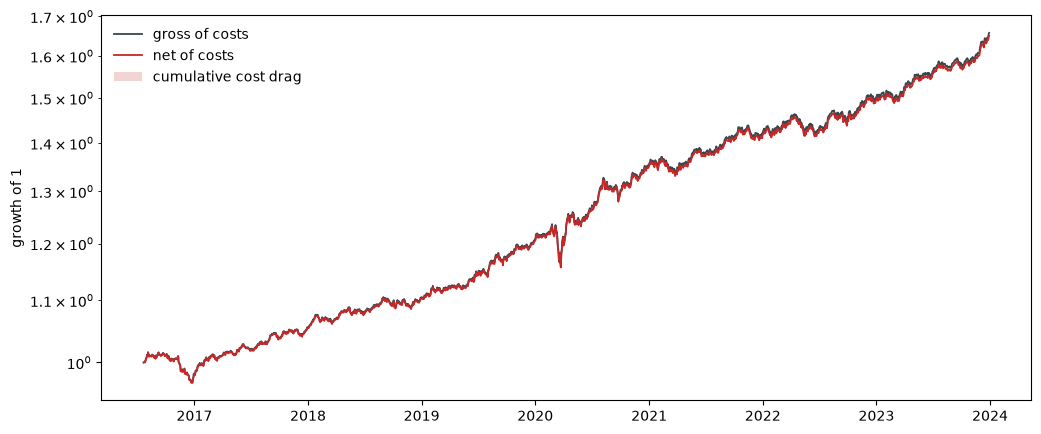

In [13]:
_ = gross_vs_net(books["hmm_conditional"])

## 6. Deflation: how much of this is luck?

A Sharpe reported once, from one strategy out of several tried, is a biased number. The deflated
Sharpe charges for the number of variants actually searched; the confidence interval comes from a
stationary bootstrap whose block length is read off the data (Politis-White) rather than guessed.

hmm_conditional      block=  2.3d  CI=( 0.050,  1.558)  DSR@7=0.764


hmm_unconditional    block=  2.0d  CI=( 0.011,  1.469)  DSR@7=0.697


hmm_vol_targeted     block=  2.3d  CI=( 0.050,  1.558)  DSR@7=0.764


vol_rule_ablation    block=  2.4d  CI=( 0.082,  1.589)  DSR@7=0.783


60_40                block=  9.1d  CI=(-0.155,  1.436)  DSR@7=0.552


equal_weight         block=  1.6d  CI=( 0.070,  1.558)  DSR@7=0.752


hmm_drawdown_feat    block=  2.4d  CI=( 0.096,  1.605)  DSR@7=0.805


jump_regime          block=  2.6d  CI=( 0.033,  1.590)  DSR@7=0.767


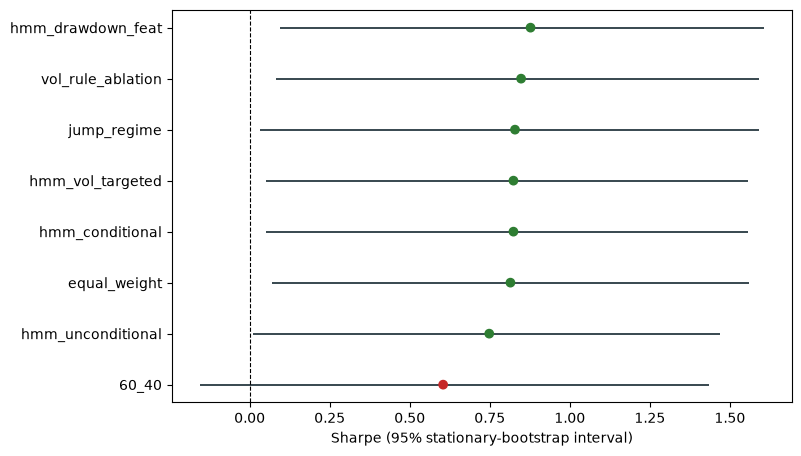

In [14]:
TRIALS = 7  # rank_vol, rank_return, conditional/unconditional, vol rule, jump, vol target, drawdown
sharpes, cis = {}, {}
for name, book in books.items():
    excess = book["ret_net"] - rf / 252.0
    sharpes[name] = sharpe(excess)
    cis[name] = bootstrap_ci(excess, n_boot=2000)
    print(f"{name:20s} block={optimal_block_length(excess):5.1f}d  "
          f"CI=({cis[name][0]:6.3f}, {cis[name][1]:6.3f})  "
          f"DSR@{TRIALS}={deflated_sharpe(excess, TRIALS, 0.4):.3f}")
_ = sharpe_forest(sharpes, cis)

Every interval is roughly 1.5 Sharpe points wide on 1814 days. The ranking at the top of the table
is not distinguishable from the ranking at the bottom of it, and any story resting on a 0.03 Sharpe
gap is a story about noise.

Note which book tops the table: the drawdown-feature variant. It is **not** being counted as a win.
Its success criterion was pre-registered before any Sharpe was computed - the crisis label's
next-day return had to turn negative - and that label came out at +29.7%. It failed on its own
terms, and promoting it afterwards on a metric it was not tested against is precisely the selection
bias the deflated Sharpe exists to punish.

## 7. The regimes themselves

The overlay uses walk-forward out-of-sample labels, so nothing here had access to its own future.

Text(0.5, 1.0, 'INDIA equity, walk-forward out-of-sample regimes')

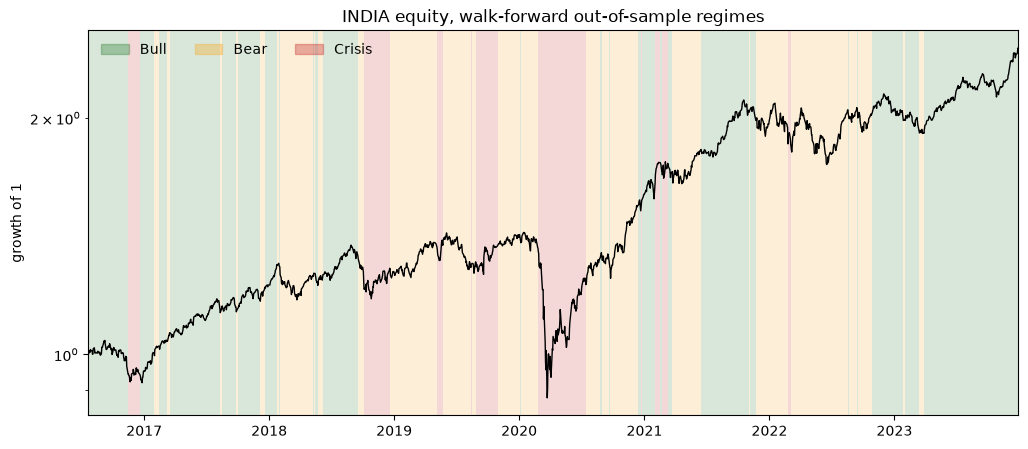

In [15]:
level = np.exp(master["equity_ret"].cumsum()).loc[oos]
ax = regime_overlay(level / level.iloc[0], regimes)
ax.set_title(f"{MARKET.upper()} equity, walk-forward out-of-sample regimes")

Text(0.5, 1.0, 'INDIA every book, net of 7.5 bps')

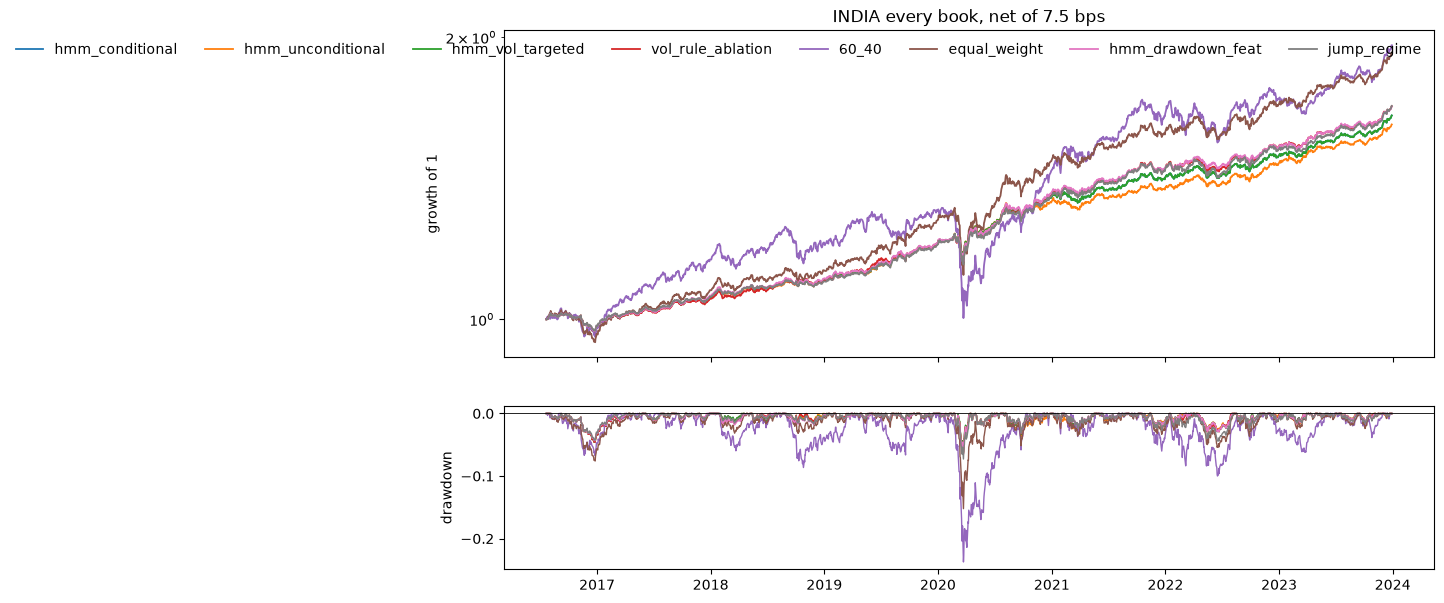

In [16]:
axes = equity_drawdown(books)
axes[0].set_title(f"{MARKET.upper()} every book, net of {cfg.costs_bps} bps")

[[0.983 0.017 0.   ]
 [0.021 0.976 0.003]
 [0.    0.032 0.968]]


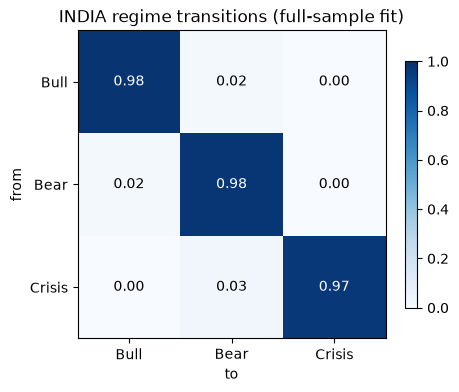

In [17]:
model = RegimeModel(n_states=cfg.hmm.n_states, **hmm_kwargs).fit(
    scaled, rank_by=feats["vol_21"].to_numpy())
ax = transition_heatmap(model.transition_matrix())
ax.set_title(f"{MARKET.upper()} regime transitions (full-sample fit)")
print(np.round(model.transition_matrix(), 3))

The diagonal runs 0.97 to 0.98: the states are genuinely persistent, not a coin flip relabelled.
The zeros in the corners matter too. Bull never jumps straight to Crisis and Crisis never jumps
straight to Bull; the market always passes through the middle state. That is economically sensible
behaviour, and it is not something the model was told to produce.

## 8. A second estimator, and a second universe

Two independent checks on whether the failure is the HMM or the state space.

**A different estimator.** A Statistical Jump Model penalizes switching directly instead of
modelling transition probabilities, so it partitions the same data on genuinely different terms.

In [18]:
for name, labels in label_sets.items():
    print(f"=== {name} ===")
    print(label_profile(labels, master).to_string())
    print("  dwell:", {k: round(v, 1) for k, v in dwell_times(labels.to_numpy()).items()}, "\n")
if "jump" in label_sets:
    print("hmm/jump label agreement:", round(float((label_sets["jump"] == regimes).mean()), 3))

=== hmm ===
       days  eq_ann_ret  eq_ann_vol  eq_sharpe  vix_mean
label                                                   
0       821       0.102       0.112      0.921    13.582
1       731       0.150       0.149      1.013    17.913
2       261       0.184       0.317      0.695    26.443
  dwell: {0: 30.4, 2: 18.6, 1: 24.4} 

=== hmm_drawdown ===
       days  eq_ann_ret  eq_ann_vol  eq_sharpe  vix_mean
label                                                   
0       736       0.093       0.102      0.924    13.211
1       827       0.122       0.154      0.827    17.840
2       250       0.297       0.319      0.976    26.682
  dwell: {0: 30.7, 1: 25.1, 2: 22.7} 

=== jump ===
       days  eq_ann_ret  eq_ann_vol  eq_sharpe  vix_mean
label                                                   
0      1272       0.169       0.137      1.206    16.036
1       447       0.107       0.138      0.804    16.430
2        94      -0.171       0.466     -0.167    36.192
  dwell: {1: 111.8, 0

The Jump Model's India crisis label looks like the discovery of the notebook: 94 days at -17.1%
annualized, the only state anywhere in this project whose forward return is negative.

**It is not a discovery, and seeing why is worth more than the result would have been.** Those 94
days are not 94 independent observations. Counting contiguous runs rather than rows gives *two
episodes*:

```
2020-03-06 -> 2020-06-12   64 days   -10.70%   <- COVID
2018-10-11 -> 2018-11-26   30 days    +4.41%   <- positive
```

Drop COVID and the same label runs **+30.17% annualized** over the remaining 40 days, which is the
identical backwards ordering as every other state in this project. The effective sample size behind
"the Jump Model finds a directional state" is one event.

`pd.crosstab(regimes, jump)` finishes it off: all 94 of those days fall inside the HMM's own crisis
label, so the Jump Model was never partitioning the data differently. It applied a stricter
threshold to the same state and happened to isolate March 2020.

The general lesson is the one worth carrying out of this notebook. Every table above reports
`n = 1814` days, but a claim about a *regime* is supported by the number of times that regime
occurred, not the number of days it spanned. The HMM's crisis label spans 261 days across just 14
episodes; the jump label, 94 days across 2. Daily-return confidence intervals are computed with a
block length read off return autocorrelation (about 2.3 days) when regimes persist for roughly 25,
so every interval attached to a regime-level claim in this notebook is too tight. Effective sample
size, not row count, is what a regime result rests on.

In [19]:
us_master = build_master(cfg.universes["us"], cfg.dates["start"], cfg.dates["end"],
                         cfg.macro_fred_series)
us_feats = build_features(us_master, cfg)
us_regimes = run_walk_forward(us_feats, cfg)
us_oos = us_regimes.index

us_books = {
    "hmm_conditional":   run_backtest(us_regimes, us_master, cfg, conditional=True),
    "vol_rule_ablation": run_backtest(vol_rule_regimes(us_master, cfg).loc[us_oos], us_master, cfg),
    "60_40":             sixty_forty(us_master, us_oos, cfg),
    "equal_weight":      equal_weight(us_master, us_oos, cfg),
}
print(f"US OOS {us_oos[0].date()} -> {us_oos[-1].date()}  n={len(us_oos)}   (rf=0, no cash sleeve)")
print(pd.DataFrame({k: summary(v) for k, v in us_books.items()}).T.round(3)
        .sort_values("sharpe", ascending=False).to_string())
print()
print(label_profile(us_regimes, us_master).to_string())
print()
print("US BIC:", {k: round(v) for k, v in bic_sweep(
    StandardScaler().fit_transform(us_feats.to_numpy(dtype=float)), **hmm_kwargs).items()})

US OOS 2016-07-05 -> 2023-12-29  n=1886   (rf=0, no cash sleeve)
                   ann_return  ann_vol  sharpe  sortino  max_drawdown  calmar    psr  turnover_ann  cost_drag_ann
vol_rule_ablation       0.098    0.103   0.958    1.369        -0.219   0.446  0.995         3.612          0.003
60_40                   0.075    0.115   0.690    0.956        -0.276   0.273  0.969         0.409          0.000
equal_weight            0.059    0.096   0.650    0.921        -0.230   0.258  0.961         0.421          0.000
hmm_conditional         0.049    0.096   0.542    0.765        -0.287   0.170  0.930         4.188          0.003

       days  eq_ann_ret  eq_ann_vol  eq_sharpe  vix_mean
label                                                   
0       665       0.109       0.087      1.229    13.029
1       841       0.147       0.156      0.955    19.299
2       379       0.161       0.322      0.626    28.110



US BIC: {2: 39821, 3: 34354, 4: 31349, 5: 29458}


**The US does not reproduce India, and saying so is the point of running it.**

What travels: the state space is volatility in both universes. US next-day returns by label run
+10.9% / +14.7% / +16.1% against volatilities of 8.7% / 15.6% / 32.2% - the same perfect volatility
ordering and the same backwards return ordering. That is now confirmed on two markets and by two
different estimators. It is the robust finding.

What does not travel: everything else. On the US the strategy loses outright, to the two-line
volatility rule (0.958) and to 60/40 (0.690) alike, and it does not buy the drawdown protection
that justified it on India, because in 2022 bonds fell alongside equities and minimum variance had
nowhere to hide. The US BIC also declines steadily with no elbow, so the K = 3 support found on
India is an Indian fact and not a general one.

A result that held on one market and was quietly assumed to hold on the other would be the more
comfortable story. It is not the one the data tells.

## Conclusion

The engine is sound and the regimes are real: persistent (diagonal 0.97-0.98), economically legible
(mean VIX 13.6 / 17.9 / 26.4), ordered without anyone labelling a day by hand, and detected with no
access to the future at any point. The pipeline is leak-proof by construction and asserted so by
tests rather than by claim.

What the data says about the strategy, at the precision the evidence supports:

1. **Volatility regimes are not return regimes.** Confirmed on both universes and by two
   estimators. A state variable has to predict direction before a directional bet on it can pay,
   and realized volatility is symmetric in sign: it cannot tell a crash from an equally violent
   rebound. This is the finding, and it is the robust one.
2. **On India the overlay buys real drawdown protection.** Max drawdown -6.2% against -15.2% for
   equal weight and -23.7% for a genuine 60/40, with Calmar roughly 1.9x and 2.8x those
   benchmarks. On Sharpe it is mid-pack and statistically indistinguishable from everything else.
   Two of the three metrics the brief names favour it; one does not.
3. **On the US it simply loses**, and the K = 3 support found on India does not appear there
   either. One universe is not evidence about the other.
4. **No directional state survives an episode count.** The Jump Model's -17.1% India crisis label
   was two episodes, one of them COVID and the other positive; ex-COVID it runs +30.17% like
   everything else, and its days sit entirely inside the HMM's own crisis label. This was written
   up as a live lead and retracted the same day by counting runs instead of rows.
5. **The rescues failed on their own terms.** Volatility targeting barely binds, because minimum
   variance already holds equity under a quarter of the book: the strategy's problem is that it is
   already too de-risked, not that it is too risky. The drawdown feature failed its pre-registered
   test outright and is not counted as a win despite topping the Sharpe table.

The config default deliberately keeps the volatility-ranked variant even though a return-ranked one
scored higher, because silently promoting the better-scoring variant is exactly the selection bias
the deflated Sharpe exists to catch. Every interval above is about 1.5 Sharpe points wide, and the
episode counts in point 4 say even that understates the uncertainty on any regime-level claim.

The strongest remaining hypothesis is not another feature but a different *use* of the states: if
they predict variance and not direction, the correct response is to size on them rather than to
de-risk on them. India's label 1 carries the highest Sharpe of any label (1.01, over 731 days) and
is routed to minimum variance, which is where most of the forgone return goes. That test is
deliberately not run here, because the deflated Sharpe is already quoted at seven trials and an
eighth would have to be declared.